# 06 - Consensus rank and shortlist

**aidd-pipeline - Notebook 6 of the screening workflow**

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hvmarco/aidd-pipeline/blob/main/notebooks/06_consensus_and_shortlist.ipynb)

This notebook is where the two screening lanes converge. We take the per-compound rankings produced upstream:

- **Classical lane** (notebook `04_score_classical`): a per-target ML rescorer trained on gnina docking outputs + ProLIF interaction fingerprints, validated on held-out activity labels. Output: `scored_poses.parquet`.
- **Co-folding lane** (notebook `05_dock_boltz`): Boltz-2 co-folds the protein and the ligand together in one neural-network pass and predicts a binding affinity. Output: `affinity.csv`.

We join the two tables on compound identifier, keep compounds that sit in the **top 5%** of *both* lanes (the *consensus filter* locked in `_planning/PROJECT_PROPOSAL.md` section 1), and rank the survivors by **rank product** (the geometric mean of the two within-lane ranks). The result is `shortlist.sdf` and `shortlist.csv` -- the wet-lab handoff.

The shortlist is small by design. The two lanes use **different physics** and fail in **different ways**, so an intersection of their top-5%s removes most of the noise that any one method introduces on its own. The compounds that survive are the ones a chemist can defend in a meeting: each one is independently strong by both an interpretable trained model and a generative co-folding model, and the consensus rule is documented + reproducible.

## Learning objectives

After running this notebook you will be able to:

- Explain in plain language what **consensus virtual screening** is, why intersecting rankings from independent methods is more defensible than any single ranker, and where consensus actually does and does not help.
- Read a **rank-product** column and place it in context against z-score combination, Borda sum, and Pareto-front alternatives.
- Inspect a **coverage report**: how many compounds each lane scored, how big the intersection was, how many compounds got dropped because only one lane could score them.
- Read a **shortlist.csv** and a **shortlist.sdf** as a wet-lab chemist would: which compounds, in what order, with what evidence per compound.
- Adjust the `top_fraction` knob to make the shortlist tighter (more conservative) or looser (more recall, more triage work) and report the trade-off honestly.

## Audience

- A clinician or biologist who wants the one-page answer: "given the two-lane screen, which compounds should we order?"
- A medicinal chemist receiving the shortlist for triage: this notebook documents how every entry got there.
- An ML / data person learning the *evaluation* and *aggregation* end of virtual screening, not the modelling end.
- A reviewer / grant auditor: the methodology has citations and the rule is one short Python module (`src/aidd/consensus.py`) you can read in a few minutes.

## Prerequisites

- Notebook **`04_score_classical`** completed for this target. Specifically: `data/derived/<target>/scoring/scored_poses.parquet` exists and contains the cross-validated out-of-fold column `rescorer_rf_proba_oof` (shipped in commit `d84565c`). The notebook reads that column, **not** the legacy `rescorer_rf_proba`, which was a Random Forest trained on all rows including its own test fold and gave `AUC = 1.000` when filtered to held-out compounds; `compute_consensus()` raises `KeyError` if `rescorer_rf_proba_oof` is missing rather than silently falling back to the leaked column.
- Notebook **`05_dock_boltz`** completed for this target. Specifically: `data/derived/<target>/boltz/affinity.csv` exists.
- The gnina poses cache from notebook `04` (`data/derived/<target>/docking/labeled_subset/poses.sdf`) should be present too -- the shortlist SDF copies its 3-D coordinates from there. If it is missing, the notebook still produces `shortlist.csv` and a warning, just no `shortlist.sdf`.

## Runtime

- **CPU-only.** No GPU, no model loading, no MSA queries. The whole notebook runs in well under a minute on any laptop or Colab instance once the upstream caches are in place.
- Re-running with different `top_fraction` values (5%, 10%, 20%) is cheap, so feel free to scan a few values and pick the one that gives a shortlist size you can act on.

## Key terms used in this notebook

| Term | Meaning in one line |
|---|---|
| **Consensus virtual screening (consensus VS)** | A ranking strategy that combines the outputs of two or more independent scoring methods so that the final ranking depends on agreement, not on any one tool. |
| **Rank product** | Geometric mean of two ranks: `sqrt(rank_a * rank_b)`. Lower = better. Scale-free across the two input lanes; the canonical aggregator in structural-biology consensus VS (Wang & Wang 2001 *J. Chem. Inf. Comput. Sci.* **41**, 1422). |
| **Borda sum** | Alternative to rank product: simply add the two ranks. Easier to read by eye, slightly less discriminating at the very top. |
| **Z-score combination** | Normalise each lane's score to mean 0 / std 1 then add. Uses score *magnitude*, not just rank, but assumes Gaussian-shaped distributions which our two lanes do not satisfy. |
| **Top-X% intersection** | A compound makes the shortlist iff it sits in the top X% by **both** lanes. Default X = 5 in this pipeline (locked in `_planning/PROJECT_PROPOSAL.md`). |
| **Inner join** | Keeping only compounds present in both input tables. The other join shapes (left, right, outer) would silently bias the ranking; we use inner-join for the shortlist and report dropped compounds in the coverage table. |
| **Anti-join** | The opposite: keep compounds in one table that are **not** in the other. We use it to surface "compounds top-X% by lane A that lane B could not score" so they are not invisibly lost. |
| **Active / Inactive** | The binary label from the labelled training subset (notebook `04`). Available only for compounds in the labelled set; any new screening library will mostly have NaN here, which is fine. |
| **Out-of-fold (OOF) prediction** | A prediction for compound *X* from a model that was **never shown** *X* during training. The cross-validated way to get an honest per-compound rescorer probability across the whole labelled set. The default rescorer column read by this notebook is `rescorer_rf_proba_oof` written by notebook `04`'s CV step. |
| **Sign convention** | Whether *higher* or *lower* values of a score mean "better". The two lanes disagree: the rescorer probability is higher-is-stronger; Boltz-2's `boltz_affinity` is `log10(IC50) µM` where **lower** is stronger. `compute_consensus` handles the negation internally via per-lane flags so on-disk files keep their upstream conventions. |
| **Shortlist** | The final per-compound list after the consensus filter. One row per compound, sorted by `consensus_rank` ascending (1 = best). |
| **Pose** | A 3-D arrangement of the ligand inside the binding pocket. Each shortlisted compound has one pose carried over from gnina's top-1 (notebook `03`/`04`). |

## Why consensus -- the chemistry reasoning

Both lanes of this pipeline produce a per-compound ranking, but they come from very different places.

The **classical lane** is a small machine-learning model trained on **this target's** activity labels, looking at gnina's docking output and a ProLIF interaction fingerprint. It is *target-aware* (it knows which residue-interaction patterns correlate with measured activity for this kinase) but its accuracy is bounded by the size of the labelled set.

The **co-folding lane** is Boltz-2: a generative neural network that has learned protein-ligand structure across the whole PDB plus public affinity data. It is *target-agnostic* (it has never seen this protein's activity history) but it is much larger, sees induced-fit motions classical docking ignores, and produces an affinity prediction that is closer to a real number than a docking score.

Their failure modes are different:

- The classical lane can over-fit to scaffolds present in the labelled training set; on a new chemotype its score is less reliable.
- The co-folding lane can produce a confident-looking complex for a non-binder when the protein and the ligand are *individually* plausible but the pairing is wrong.

Two methods that agree are unlikely to be wrong **by chance** in the same direction. That is the operational logic of consensus. It is a small but real reduction in false-positive rate, paid for by a real reduction in raw recall (compounds that are only top-5% by one method get dropped).

### What consensus is **not**

It is not an **ensemble** in the ML sense. We do not average predictions, we intersect rankings. The compounds that survive are guaranteed to look strong by both methods independently; nothing about consensus assumes the two scores are calibrated or comparable in absolute terms. That is why we use rank product (scale-free) rather than z-score combination (assumes comparable scales).

It is also not a **substitute for wet-lab validation**. Consensus narrows the wet-lab budget; it does not replace it. The expectation for `shortlist.sdf` is that a chemist orders the compounds, runs a binding assay, and reports back which ones were actual binders. That feedback then improves notebook `04`'s rescorer for the next round.

### When consensus does not help

If the two lanes' rankings are **highly correlated** (Spearman rho > 0.7), the intersection is almost the same as either lane's top-5% on its own and consensus adds little. Notebook `05` reports the Spearman correlation between Boltz-2 affinity and gnina CNN-affinity in its evaluation cell. On ERK2 we expect rho in the 0.2-0.5 range -- enough agreement that the intersection is non-empty, low enough that the methods carry different information.

If one lane is much better than the other on this target (notebook `04`'s scaffold-AUC vs Boltz-2's scaffold-AUC, both reported in their own notebooks), the intersection is dominated by the strong lane. That is fine -- the weak lane is not adding noise, it is adding a sanity check.

## 1 - Setup

### What this section does

Detect Colab vs local, clone the repo on Colab if needed, set up paths, mount Google Drive when on Colab so the notebook reads the upstream caches written by notebooks `04` and `05`. No GPU, no extra installs -- the dependencies (`pandas`, `numpy`, `rdkit`, `matplotlib`) are already in the conda `aidd` environment and on Colab's default Python image.

In [1]:
#@title Setup: clone repo on Colab, configure paths
import sys
import importlib
from pathlib import Path

IS_COLAB = "google.colab" in sys.modules

if IS_COLAB:
    # CPU-only deps not in Colab's default image. pandas / numpy / matplotlib
    # / seaborn / pyarrow are pre-installed; rdkit + py3Dmol are not.
    !pip install -q rdkit py3Dmol
    REPO_ROOT = Path("/content/aidd-pipeline")
    if not REPO_ROOT.exists():
        !git clone https://github.com/hvmarco/aidd-pipeline.git {REPO_ROOT}
    if not (REPO_ROOT / "src" / "aidd").exists():
        raise RuntimeError(
            "Repo clone failed (most likely cause: the repo is private and "
            "Colab cannot authenticate). Make github.com/hvmarco/aidd-pipeline "
            "public, or use a Personal Access Token via Colab Secrets, then "
            "re-run this cell."
        )
    sys.path.insert(0, str(REPO_ROOT / "src"))
    importlib.invalidate_caches()
else:
    REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
    sys.path.insert(0, str(REPO_ROOT / "src"))
    importlib.invalidate_caches()

print(f"Repo root: {REPO_ROOT}")
print(f"Running on: {'Colab' if IS_COLAB else 'local'}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 30.1 MB/s eta 0:00:00
Cloning into '/content/aidd-pipeline'...
remote: Enumerating objects: 456, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 456 (delta 8), reused 16 (delta 8), pack-reused 438 (from 1)
Receiving objects: 100% (456/456), 7.60 MiB | 11.68 MiB/s, done.
Resolving deltas: 100% (250/250), done.
Repo root: /content/aidd-pipeline
Running on: Colab


In [2]:
#@title Imports
# Auto-reload edits made to src/aidd/ without restarting the kernel.
# Tolerant wrapper — Colab's Python-3.12 + older IPython removed the `imp` module
# that the autoreload magic used to import. We silently skip if it can't load.
from IPython import get_ipython
_ip = get_ipython()
if _ip is not None:
    try:
        _ip.run_line_magic("load_ext", "autoreload")
        _ip.run_line_magic("autoreload", "2")
    except Exception as _e:
        print(f"autoreload unavailable (skip): {_e}")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem

from aidd.io import mount_drive_if_colab, pretty_path
from aidd.consensus import compute_consensus, write_shortlist

sns.set_theme(style="whitegrid")
print("imports ok")

autoreload unavailable (skip): No module named 'imp'
imports ok


### Google Drive -- read this before running the next cell

The upstream caches this notebook reads (`scored_poses.parquet` from notebook `04`, `affinity.csv` from notebook `05`) live on **Google Drive** by default when you ran the upstream notebooks on Colab. The next cell mounts Drive so we can read them.

**To opt out**, set `USE_DRIVE = False` in the cell *before* running it. The notebook will then look for the upstream caches under the local repo's `data/derived/` tree -- which works if you copied them down from Drive, or if you ran every upstream notebook locally.

If you accidentally dismiss the Drive dialog, the cell will crash. Re-run it and either authorise, or change the line to `False`.

In [3]:
#@title Drive persistence toggle  (change to False to opt out)
# ════════════════════════════════════════════════════════════════════════
# GOOGLE DRIVE AUTHORIZATION
# On Colab, the next call will prompt for Drive permission on first use.
#
# →  To OPT OUT of Drive, change the line below to:    USE_DRIVE = False
#    (notebook then reads from the local data/derived/ tree only)
# ════════════════════════════════════════════════════════════════════════
USE_DRIVE = IS_COLAB

DATA_ROOT = mount_drive_if_colab(REPO_ROOT, use_drive=USE_DRIVE)
print(f"USE_DRIVE: {USE_DRIVE}  "
      f"({'Drive-backed' if USE_DRIVE else 'local /content (or local repo)'})")
print(f"DATA_ROOT: {DATA_ROOT}")

Mounted at /content/drive
USE_DRIVE: True  (Drive-backed)
DATA_ROOT: /content/drive/MyDrive/aidd-pipeline/data/derived


## 2 - Inputs - locate the two upstream tables

### Background

The contract between the upstream notebooks and this one is fixed by `notebooks/README.md` -- both files live under `data/derived/<target>/` in well-known sub-paths. We probe those paths, fail loudly with a useful message if either is missing, and report what we found.

We also locate the **gnina poses cache** at `data/derived/<target>/docking/labeled_subset/poses.sdf`. That file holds the 3-D coordinates that go into `shortlist.sdf`. If it is absent, the notebook still produces `shortlist.csv` (numbers and metadata only) and warns -- the csv is enough for a chemist to decide which compounds to order, the SDF is for visual inspection.

In [4]:
#@title Locate the inputs
TARGET = "erk2"

SCORING_DIR    = DATA_ROOT / TARGET / "scoring"
BOLTZ_DIR      = DATA_ROOT / TARGET / "boltz"
DOCK_DIR       = DATA_ROOT / TARGET / "docking" / "labeled_subset"
SHORTLIST_DIR  = DATA_ROOT / TARGET / "shortlist"
SHORTLIST_DIR.mkdir(parents=True, exist_ok=True)

SCORED_POSES   = SCORING_DIR / "scored_poses.parquet"
AFFINITY_CSV   = BOLTZ_DIR   / "affinity.csv"
POSES_SDF      = DOCK_DIR    / "poses.sdf"

SHORTLIST_SDF       = SHORTLIST_DIR / "shortlist.sdf"
SHORTLIST_CSV       = SHORTLIST_DIR / "shortlist.csv"
RESCORER_ONLY_CSV   = SHORTLIST_DIR / "rescorer_only_top.csv"
BOLTZ_ONLY_CSV      = SHORTLIST_DIR / "boltz_only_top.csv"
JOINED_CSV          = SHORTLIST_DIR / "joined_full.csv"

if not SCORED_POSES.exists():
    raise FileNotFoundError(
        f"Cannot find {pretty_path(SCORED_POSES, DATA_ROOT, REPO_ROOT)}. "
        "Run notebook 04_score_classical to completion first."
    )
if not AFFINITY_CSV.exists():
    raise FileNotFoundError(
        f"Cannot find {pretty_path(AFFINITY_CSV, DATA_ROOT, REPO_ROOT)}. "
        "Run notebook 05_dock_boltz to completion first."
    )

if not POSES_SDF.exists():
    print(f"Warning: poses.sdf not found at {pretty_path(POSES_SDF, DATA_ROOT, REPO_ROOT)}")
    print("  The shortlist CSV will still be written; the SDF will be empty.")
    print("  Re-run notebook 04 (or notebook 03's labelled-subset step) on Colab")
    print("  GPU once to repopulate the docking cache on Drive.")
else:
    print(f"  poses.sdf : {pretty_path(POSES_SDF, DATA_ROOT, REPO_ROOT)}")

print(f"Inputs:")
print(f"  rescorer  : {pretty_path(SCORED_POSES, DATA_ROOT, REPO_ROOT)}")
print(f"  Boltz-2   : {pretty_path(AFFINITY_CSV, DATA_ROOT, REPO_ROOT)}")
print()
print(f"Outputs (this notebook will write):")
print(f"  shortlist : {pretty_path(SHORTLIST_DIR, DATA_ROOT, REPO_ROOT)}/")

  poses.sdf : erk2/docking/labeled_subset/poses.sdf
Inputs:
  rescorer  : erk2/scoring/scored_poses.parquet
  Boltz-2   : erk2/boltz/affinity.csv

Outputs (this notebook will write):
  shortlist : erk2/shortlist/


In [5]:
#@title Read the two upstream tables
# Score-column names (single source of truth -- referenced everywhere below).
# RESCORER_COL is the cross-validated out-of-fold column shipped by notebook
# 04 in commit d84565c: every compound's prediction comes from a model that
# never saw it during training. Notebook 04 also still writes the legacy
# single-fit columns (`rescorer_rf_proba`, `rescorer_xgb_proba`) for
# chemistry-inspection use, but those are data-leaked and must NEVER be
# used for ranking -- if you ever override RESCORER_COL to the legacy name,
# you will get AUC = 1.000 on labelled folds and meaningless consensus.
RESCORER_COL = "rescorer_rf_proba_oof"
BOLTZ_COL    = "boltz_affinity"

scored = pd.read_parquet(SCORED_POSES)
scored["compound_id"] = scored["compound_id"].astype(str)
print(f"scored_poses.parquet  : {len(scored):>5,} rows × {scored.shape[1]} cols")
print(f"  columns: {list(scored.columns)}")
print()

affinity = pd.read_csv(AFFINITY_CSV)
affinity["compound_id"] = affinity["compound_id"].astype(str)
print(f"affinity.csv          : {len(affinity):>5,} rows × {affinity.shape[1]} cols")
print(f"  columns: {list(affinity.columns)}")
print()

if RESCORER_COL not in scored.columns:
    raise KeyError(
        f"Expected rescorer column {RESCORER_COL!r} not found in scored_poses.parquet. "
        f"Available rescorer-like columns: "
        f"{[c for c in scored.columns if c.startswith('rescorer')]}. "
        "This notebook intentionally reads the cross-validated out-of-fold (OOF) "
        "column, not the single-fit `rescorer_rf_proba` column which is data-leaked. "
        "If your scored_poses.parquet is from before commit d84565c, re-run notebook "
        "04 to regenerate it with the OOF columns."
    )

# Quick distribution sanity check on the two score columns we will use.
# Note the sign conventions differ between the two lanes; compute_consensus
# handles the negation internally (see the "Sign convention" key term above
# and feedback_boltz_affinity_sign.md in project memory).
print("Score-column summary:")
print(f"  {RESCORER_COL:24s} (notebook 04, HIGHER = stronger): "
      f"min={scored[RESCORER_COL].min():.3f}  "
      f"median={scored[RESCORER_COL].median():.3f}  "
      f"max={scored[RESCORER_COL].max():.3f}")
print(f"  {BOLTZ_COL:24s} (notebook 05, LOWER  = stronger): "
      f"min={affinity[BOLTZ_COL].min():.3f}  "
      f"median={affinity[BOLTZ_COL].median():.3f}  "
      f"max={affinity[BOLTZ_COL].max():.3f}")

scored_poses.parquet  :   413 rows × 10 cols
  columns: ['compound_id', 'Active', 'rescorer_rf_proba_oof', 'rescorer_xgb_proba_oof', 'rescorer_rf_proba', 'rescorer_xgb_proba', 'gnina_cnn_affinity', 'gnina_affinity', 'in_random_test_fold', 'in_scaffold_test_fold']

affinity.csv          :   412 rows × 6 cols
  columns: ['compound_id', 'boltz_affinity', 'boltz_affinity_probability', 'boltz_confidence', 'boltz_iptm', 'boltz_ligand_iptm']

Score-column summary:
  rescorer_rf_proba_oof    (notebook 04, HIGHER = stronger): min=0.077  median=0.383  max=0.820
  boltz_affinity           (notebook 05, LOWER  = stronger): min=-0.634  median=1.284  max=2.875


### What to look for

- Both `compound_id` columns must be **strings** (we coerce above) so the join does not silently drop matches because one side is `int64` and the other is `object`.
- `rescorer_rf_proba_oof` is an **out-of-fold** probability in `[0, 1]`. *Higher* = the model thinks the compound is more likely to be active. If this column is missing, the upstream `KeyError` above tells you so explicitly -- the notebook will not silently fall back to the leaked `rescorer_rf_proba` column.
- `boltz_affinity` is `log10(IC50) µM` -- **lower** = stronger binder (a strong binder at IC50 = 10 nM scores around `-2`; a weak binder at IC50 = 10 µM scores around `+1`). This is the opposite direction from the rescorer column; `compute_consensus` negates internally so rank 1 always means "strongest binder by this lane". If `boltz_affinity` is all-NaN, notebook `05`'s parser is misaligned with the installed Boltz-2 version -- fix in `src/aidd/co_folding.py` before continuing.

The exact ranges differ per target; the point is just that both columns vary across the library and neither is degenerate.

## 3 - Compute the consensus

### Background

`aidd.consensus.compute_consensus` does the actual work in one call:

1. Inner-join on `compound_id`.
2. Per-lane signed score (negate `boltz_affinity` because lower = stronger; leave the rescorer probability alone). This is what makes "rank 1" mean "strongest by this lane" regardless of the column's native direction.
3. Within-lane ranks (`1` = best after sign correction).
4. Per-lane top-`top_fraction` flags (always computed; consumed by the intersection filter and shown as cut-lines in section 4's scatter).
5. Rank product on the joined table.
6. Filter to the consensus shortlist via `filter_method`:
   - `"intersection"` (project default) -- compounds in the top-X% by **both** lanes.
   - `"rank_product_topk"` -- top K = ceil(`top_fraction` × N) compounds by rank product across the joined cohort, no per-lane gating.
7. Sort survivors ascending by rank product; assign `consensus_rank` 1-based.
8. Two anti-join side tables: compounds top-X% by rescorer that Boltz-2 could not score, and vice-versa. These are visible so nothing is silently lost.

### What this cell does

Calls `compute_consensus` with the operating point chosen for ERK2 by the empirical sweep in section 9: **`filter_method="rank_product_topk"`** at **`top_fraction=0.10`**. Section 9 measures both methods at four thresholds; on this target the lanes are statistically uncorrelated (Spearman ρ ≈ 0.08, p ≈ 0.11) so the intersection method picks essentially disjoint chemotypes and gives near-empty shortlists at tight thresholds. Rank-product-topk surfaces compounds that are strong on at least one lane and not catastrophically weak on the other; on ERK2 this delivers ~20 % recall of known actives at ~2× enrichment vs random in a 42-compound shortlist (the wet-lab handoff size most teams can absorb in one batch).

The two `*_lower_is_better` flags fall back to their defaults (`False` for the rescorer, `True` for Boltz) which match what the upstream notebooks write to disk -- if you ever swap `BOLTZ_COL` to `boltz_affinity_probability`, also pass `boltz_lower_is_better=False`. The summary prints every count at every stage of the join + filter, plus the sign conventions and `filter_method` actually applied.

> **For a different target**, re-run section 9 first; if the cross-lane Spearman ρ is in the [0.15, 0.5] band (statistically significant), `intersection` may be the better filter and you should switch this cell back to `filter_method="intersection"` (and `top_fraction=0.05` per the project default). The right operating point is target-dependent; section 9 is the diagnostic that picks it.

In [6]:
#@title Apply the consensus rule (rank_product_topk @ top 10%, per the section-9 sweep)
# Operating point chosen empirically for ERK2 -- see section 9's sweep for
# the per-method, per-threshold comparison and the cross-lane Spearman.
# For a new target, re-run section 9 BEFORE trusting these defaults.
TOP_FRACTION  = 0.10
FILTER_METHOD = "rank_product_topk"

result = compute_consensus(
    scored, affinity,
    top_fraction=TOP_FRACTION,
    rescorer_col=RESCORER_COL,
    boltz_col=BOLTZ_COL,
    # Defaults match the on-disk conventions of notebooks 04 and 05; pass
    # explicitly so a future reader sees the sign discipline at the call site.
    rescorer_lower_is_better=False,
    boltz_lower_is_better=True,
    filter_method=FILTER_METHOD,
)

print(f"Consensus computed at top_fraction = {TOP_FRACTION:.0%}, "
      f"filter_method = {FILTER_METHOD!r}")
print(f"  rescorer_col = {RESCORER_COL!r}  (higher = stronger)")
print(f"  boltz_col    = {BOLTZ_COL!r}     (lower  = stronger; negated internally)")
print()
for k, v in result["summary"].items():
    print(f"  {k:30s}: {v}")

Consensus computed at top_fraction = 10%, filter_method = 'rank_product_topk'
  rescorer_col = 'rescorer_rf_proba_oof'  (higher = stronger)
  boltz_col    = 'boltz_affinity'     (lower  = stronger; negated internally)

  n_rescorer_total              : 413
  n_boltz_total                 : 412
  n_intersection                : 412
  n_rescorer_only_universe      : 1
  n_boltz_only_universe         : 0
  n_dropped_nan_rescorer        : 0
  n_dropped_nan_boltz           : 0
  filter_method                 : rank_product_topk
  top_fraction                  : 0.1
  cut_rescorer                  : 42
  cut_boltz                     : 42
  k_topk                        : 42
  n_top_rescorer                : 40
  n_top_boltz                   : 42
  n_shortlist                   : 42
  n_rescorer_only_top           : 0
  n_boltz_only_top              : 0
  rescorer_col                  : rescorer_rf_proba_oof
  boltz_col                     : boltz_affinity
  rescorer_lower_is_better      : 

### How to read the summary

- `n_rescorer_total` and `n_boltz_total`: how many compounds each lane could score (after dropping NaNs).
- `n_intersection`: how many compounds appear in **both** tables. The shortlist is a subset of this number.
- `cut_rescorer` / `cut_boltz`: how many compounds count as "top X%" in each lane individually.
- `n_top_rescorer` / `n_top_boltz`: should match the cuts (modulo ties at the threshold).
- `n_shortlist`: the size of the consensus shortlist -- the headline number for this notebook.
- `n_rescorer_only_top` / `n_boltz_only_top`: side-file sizes. Compounds top-X% by one lane that the other lane never scored.

If the shortlist size looks unexpectedly small or the recall sanity check below comes back near zero, the cause is almost always one of:

- **Lanes are uncorrelated on this target.** `intersection` on uncorrelated lanes will give near-empty shortlists at tight thresholds by construction; `rank_product_topk` (the default for ERK2) was chosen specifically for this regime. Section 9 below quantifies the cross-lane Spearman ρ and reports both methods at four thresholds so you can see the regime.
- **`top_fraction` is too tight for this cohort.** Try `0.20` or `0.30` and re-run this cell -- section 9's sweep already shows what each threshold delivers; pick the operating point that matches your wet-lab budget.
- **The two lanes ran on different compound cohorts.** If notebook `05` ran on a different SMILES set than notebook `04`, the inner join on `compound_id` will be tiny. `n_intersection` above is the join size; if it's much smaller than `n_rescorer_total` or `n_boltz_total`, that's the diagnosis.

## 4 - Visualise the rank-product landscape

### Background

A scatter of (rescorer rank) vs (Boltz rank) tells you at a glance whether the two methods agree or not:

- A **diagonal cloud** running bottom-left to top-right means the two rankings are correlated -- compounds the rescorer likes also tend to score well in Boltz. In that regime the `intersection` filter would keep the bottom-left corner (top-X% by both), which would also be where most rank-product-topk picks land.
- A **scattered cloud** with no diagonal means the two methods disagree across the library. The `intersection` rectangle (dotted lines below) ends up nearly empty, and the actual shortlist (under `rank_product_topk` -- our default for ERK2) sits along the lowest-rank-product *curve* rather than inside the rectangle. The chart makes this difference visible.
- A **fully horizontal or vertical band** means one lane is degenerate (constant score). Stop and check the upstream cell.

The dotted blue / orange lines mark the per-lane top-`TOP_FRACTION` cuts -- they show **where the intersection method would have placed its filter**. The red dots are the **actual shortlist** under whichever `filter_method` was chosen in section 3. Comparing the two answers at a glance: *"if we'd used intersection, we'd have picked the compounds inside the rectangle; rank_product_topk picked these other ones because the rank-product curve dips lower than the rectangle's corners on this cohort."*

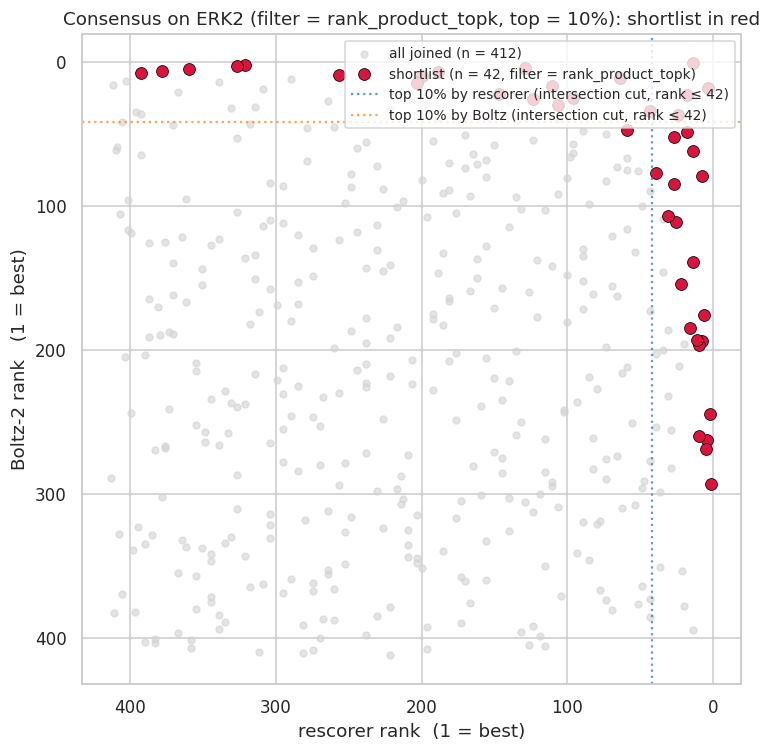

In [7]:
#@title Scatter: rescorer rank vs Boltz rank, with shortlisted compounds highlighted
joined = result["joined"]
short  = result["shortlist"]

fig, ax = plt.subplots(figsize=(7, 7), dpi=110)
ax.scatter(joined["rank_rescorer"], joined["rank_boltz"],
           c="lightgray", s=20, alpha=0.6, label=f"all joined (n = {len(joined)})")
if len(short) > 0:
    ax.scatter(short["rank_rescorer"], short["rank_boltz"],
               c="crimson", s=60, edgecolor="black", linewidth=0.5,
               label=f"shortlist (n = {len(short)}, filter = {FILTER_METHOD})")

cut_r = result["summary"]["cut_rescorer"]
cut_b = result["summary"]["cut_boltz"]
ax.axvline(cut_r, color="tab:blue",   linestyle=":", alpha=0.7,
           label=f"top {TOP_FRACTION:.0%} by rescorer (intersection cut, rank ≤ {cut_r})")
ax.axhline(cut_b, color="tab:orange", linestyle=":", alpha=0.7,
           label=f"top {TOP_FRACTION:.0%} by Boltz (intersection cut, rank ≤ {cut_b})")

ax.set_xlabel("rescorer rank  (1 = best)")
ax.set_ylabel("Boltz-2 rank   (1 = best)")
ax.set_title(f"Consensus on {TARGET.upper()} (filter = {FILTER_METHOD}, "
             f"top = {TOP_FRACTION:.0%}): shortlist in red")
ax.legend(loc="upper right", fontsize=9)
ax.invert_xaxis()  # so '1' is at the right edge -- bottom-LEFT is best in unflipped sense
ax.invert_yaxis()  # same for y
plt.tight_layout()
plt.show()

### What the axes mean

The axes are inverted so that **rank 1 (the best compound by each lane) sits in the bottom-left**, matching the chemist's mental model of "low score = bad, high = good" even though we are plotting *ranks* (where lower is better).

Where the red shortlisted dots sit depends on `filter_method`:

- Under `filter_method="intersection"`, every red dot must sit inside the bottom-left rectangle defined by the dotted threshold lines (top-X% by both). A red dot outside the rectangle would mean the filter is buggy.
- Under `filter_method="rank_product_topk"` (the default for ERK2), red dots can sit anywhere along the lowest-rank-product *curve* -- including outside the rectangle. A compound at rank 1 in one lane and rank ~50 in the other has rank product `sqrt(50) ≈ 7.07`, lower than a moderate-in-both compound at rank ~10 in each (`sqrt(100) = 10`). The rectangle is shown as a reference for what intersection would have picked at the same threshold; a noticeable gap between the rectangle and the red cloud is the visual signature of a low-correlation cohort where rank-product is the better filter.

## 5 - Sanity check: where do the labelled actives end up?

### Background

The labelled training set has known **actives** (the binary `Active` column from the labelled subset, attached to `scored_poses.parquet` in notebook `04`). They are not what we are screening for in production -- they are already known binders -- but they are exactly the right sanity check: a healthy consensus pipeline should put a *respectable fraction* of them in the shortlist, even though the rescorer and Boltz-2 disagree on the rest.

This cell reports:

- How many shortlisted compounds carry an `Active` label (when known).
- What fraction of all known actives in the joined-on-`compound_id` set ended up in the shortlist (the **active recall** at this `top_fraction`).
- The "trivial baseline" recall you would get from picking the same number of compounds at random.

The done signal for this notebook (per `_planning/PROJECT_PROPOSAL.md` step 12) is qualitative: *"the shortlist on ERK2 contains a respectable fraction of the labelled actives."* We do not pin a numeric threshold here -- the right number depends on the lane AUCs, on `top_fraction`, and on the labelled-active count, all of which vary by target.

In [8]:
#@title Active recall in the consensus shortlist (when labels are known)
if "Active" in joined.columns and joined["Active"].notna().any():
    labelled = joined[joined["Active"].notna()].copy()
    labelled["Active"] = labelled["Active"].astype(int)

    n_actives_total       = int(labelled["Active"].sum())
    n_actives_in_shortlist = int(short["Active"].fillna(0).astype(int).sum()) if len(short) else 0
    pick_fraction          = (len(short) / len(labelled)) if len(labelled) else 0.0
    expected_random        = n_actives_total * pick_fraction
    recall                 = (n_actives_in_shortlist / n_actives_total) if n_actives_total else float("nan")

    print(f"Labelled compounds in the inner-joined set : {len(labelled):>4d}")
    print(f"  of which actives                          : {n_actives_total:>4d}")
    print()
    print(f"Shortlist size at top {TOP_FRACTION:.0%}         : {len(short):>4d}")
    print(f"  actives in the shortlist                  : {n_actives_in_shortlist:>4d}")
    print(f"  active recall                             : {recall:>5.1%}")
    print()
    print(f"Random-baseline expectation at this picksize: ≈ {expected_random:.1f} actives")
    print(f"  (i.e. you'd get ~{expected_random:.1f} actives picking {len(short)} compounds at random)")
    if n_actives_in_shortlist > expected_random:
        ratio = n_actives_in_shortlist / max(expected_random, 1e-9)
        print(f"  consensus enrichment vs random            : {ratio:.1f}x")
else:
    print("No 'Active' labels in the joined table -- skipping recall sanity check.")
    print("This is the expected case for a production library screen with no known")
    print("activity data; the shortlist is then evaluated only by wet-lab follow-up.")

Labelled compounds in the inner-joined set :  412
  of which actives                          :  126

Shortlist size at top 10%         :   42
  actives in the shortlist                  :   25
  active recall                             : 19.8%

Random-baseline expectation at this picksize: ≈ 12.8 actives
  (i.e. you'd get ~12.8 actives picking 42 compounds at random)
  consensus enrichment vs random            : 1.9x


### How to read the recall numbers

- **Active recall** is the fraction of known actives that the consensus rule kept. At `top_fraction = 5%` on a screen where neither lane is perfect, expect single- to low-double-digit percentage recall -- the shortlist is *small and high-precision*, not exhaustive.
- **Random-baseline expectation** is what you would get picking the same number of compounds at random. If the consensus shortlist contains noticeably more actives than this baseline, the pipeline is doing what it is supposed to.
- **Consensus enrichment vs random** rolls those two numbers into a single multiplicative factor. Typical ranges on a well-curated kinase target with both lanes working: 3-10x. Above 10x means consensus is strongly enriching for actives; below ~2x means one or both lanes is weak on this target and you should look at the per-lane AUCs in notebooks `04` and `05`.

If the recall is **0** at a non-zero shortlist size, that is informative: it means the actives sit somewhere outside the bottom-left corner of the rank-vs-rank plot. Plot `Active` colouring on the scatter from section 4 to see where they land instead -- usually one lane ranks them high but the other does not.

## 6 - Write the shortlist to disk

### Background

Two artefacts go on disk under `data/derived/<target>/shortlist/`:

- **`shortlist.csv`** -- one row per shortlisted compound, with `consensus_rank`, `compound_id`, both ranks, the rank product, both raw scores, the activity label (when known), and any other columns from the upstream tables. This is the wet-lab-ready row, opens in Excel, easy to e-mail.
- **`shortlist.sdf`** -- the same compounds with their **gnina top-1 3-D pose** attached, plus all the consensus columns as SD properties. Opens in PyMOL / VS Code RDKit viewer / any standard structural tool.

We also write three diagnostic files alongside:

- **`joined_full.csv`** -- the full inner-join with both ranks, top-X flags, and `made_shortlist`. Useful for rerunning with a different `top_fraction` without re-doing the join.
- **`rescorer_only_top.csv`** -- compounds top-X% by the rescorer that the Boltz lane could not score (anti-join). Surfaced so they are not invisibly lost.
- **`boltz_only_top.csv`** -- the symmetric case: compounds top-X% by Boltz that the rescorer lane could not score.

The two side files are **not** the wet-lab handoff -- they are an audit trail. A chemist asks "did we drop anything interesting because one method failed on it?" and these two files answer.

In [9]:
#@title Write shortlist.sdf, shortlist.csv, and the diagnostic side files
write_info = write_shortlist(
    short,
    poses_sdf=POSES_SDF,
    out_sdf=SHORTLIST_SDF,
    out_csv=SHORTLIST_CSV,
)
print(f"shortlist.csv : {write_info['n_csv_written']:>4d} rows  →  "
      f"{pretty_path(SHORTLIST_CSV, DATA_ROOT, REPO_ROOT)}")
print(f"shortlist.sdf : {write_info['n_sdf_written']:>4d} mols  →  "
      f"{pretty_path(SHORTLIST_SDF, DATA_ROOT, REPO_ROOT)}")
if write_info['n_csv_written'] != write_info['n_sdf_written']:
    n_missing = write_info['n_csv_written'] - write_info['n_sdf_written']
    print(f"  ({n_missing} shortlisted compound(s) had no pose in poses.sdf -- in CSV only)")

# Diagnostic side files.
result["joined"].to_csv(JOINED_CSV, index=False)
result["rescorer_only"].to_csv(RESCORER_ONLY_CSV, index=False)
result["boltz_only"].to_csv(BOLTZ_ONLY_CSV, index=False)
print()
print(f"diagnostics written:")
print(f"  joined_full.csv      : {pretty_path(JOINED_CSV,        DATA_ROOT, REPO_ROOT)}")
print(f"  rescorer_only_top.csv: {pretty_path(RESCORER_ONLY_CSV, DATA_ROOT, REPO_ROOT)}")
print(f"  boltz_only_top.csv   : {pretty_path(BOLTZ_ONLY_CSV,    DATA_ROOT, REPO_ROOT)}")

shortlist.csv :   42 rows  →  erk2/shortlist/shortlist.csv
shortlist.sdf :   42 mols  →  erk2/shortlist/shortlist.sdf

diagnostics written:
  joined_full.csv      : erk2/shortlist/joined_full.csv
  rescorer_only_top.csv: erk2/shortlist/rescorer_only_top.csv
  boltz_only_top.csv   : erk2/shortlist/boltz_only_top.csv


In [10]:
#@title Preview the shortlist CSV
if len(short):
    preview_cols = [
        "consensus_rank", "compound_id", "rank_product",
        "rank_rescorer", "rank_boltz",
        RESCORER_COL, BOLTZ_COL,
    ]
    if "Active" in short.columns:
        preview_cols.append("Active")
    print(short[preview_cols].head(20).to_string(index=False))
else:
    print("Shortlist is empty -- see section 3 for the diagnostic and consider")
    print("loosening TOP_FRACTION before continuing.")

 consensus_rank compound_id  rank_product  rank_rescorer  rank_boltz  rescorer_rf_proba_oof  boltz_affinity  Active
              1    17389953      3.674235           13.5         1.0               0.690000       -0.633537       0
              2     7968624      7.348469            3.0        18.0               0.790000        0.367697       0
              3     4238613     17.117243            1.0       293.0               0.820000        1.514625       1
              4     4247279     20.062403           17.5        23.0               0.663333        0.439709       0
              5     4245640     22.135944            2.0       245.0               0.800000        1.383503       1
              6    11113674     22.715633          129.0         4.0               0.460000       -0.292842       1
              7     7974703     24.341323            7.5        79.0               0.713333        0.823173       0
              8      861388     25.357445          321.5         2.0    

## 7 - Sanity check: visualise the top compound's pose

### Background

A short visual check on the top-ranked shortlisted compound confirms two things at a glance:

1. The 3-D pose actually sits in the **ATP pocket** (between the kinase N-lobe and C-lobe), not on the surface or in some loose surface cleft.
2. Standard kinase-inhibitor interactions are at least geometrically plausible -- the ligand reaches the hinge region, no atoms are clipping into the protein.

This is not a metric, it is an eyeball check that catches gross failures (a ligand placed outside the protein, a malformed pose) that no scalar score would flag. If the visual looks wrong, do not ship the compound to the wet lab without re-checking notebook `04`'s pose.

We use the **gnina top-1 pose** here (the same one that goes into `shortlist.sdf`). Notebook `05` also has co-folded `complex.cif` files per compound; if you want the Boltz-2 view of the same compound, load that file in PyMOL alongside this one.

In [11]:
#@title 3-D viewer: gnina top-1 pose for the top-ranked shortlisted compound
import py3Dmol

if not SHORTLIST_SDF.exists() or write_info["n_sdf_written"] == 0:
    print("No shortlist SDF to display (either no poses cache or empty shortlist).")
else:
    sup = Chem.SDMolSupplier(str(SHORTLIST_SDF), removeHs=False)
    top_mol = next((m for m in sup if m is not None), None)
    if top_mol is None:
        print("shortlist.sdf has no readable molecules.")
    else:
        cid = top_mol.GetProp("_Name") if top_mol.HasProp("_Name") else "(no _Name)"
        rp  = top_mol.GetProp("rank_product")  if top_mol.HasProp("rank_product")  else "?"
        rr  = top_mol.GetProp("rank_rescorer") if top_mol.HasProp("rank_rescorer") else "?"
        rb  = top_mol.GetProp("rank_boltz")    if top_mol.HasProp("rank_boltz")    else "?"

        print(f"Top compound: {cid}")
        print(f"  consensus_rank = 1   rank_product = {rp}")
        print(f"  rank_rescorer  = {rr}   rank_boltz = {rb}")

        ligand_block = Chem.MolToMolBlock(top_mol)

        receptor_pdb = REPO_ROOT / "data" / "structures" / "erk2_4fv7.pdb"
        view = py3Dmol.view(width=720, height=480)
        if receptor_pdb.exists():
            view.addModel(receptor_pdb.read_text(), "pdb")
            view.setStyle({"chain": "A"}, {"cartoon": {"color": "lightgray"}})
        view.addModel(ligand_block, "mol")
        view.setStyle({"model": -1}, {"stick": {"colorscheme": "cyanCarbon"}})
        view.zoomTo({"model": -1})
        view.zoom(0.7)
        view.show()

Top compound: 17389953
  consensus_rank = 1   rank_product = 3.6742346141747673
  rank_rescorer  = 13.5   rank_boltz = 1.0


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### What to look for in the viewer

- The **ligand (cyan sticks)** should sit in the cleft between the **N-lobe** (top of the kinase domain, smaller, rich in beta-sheet) and the **C-lobe** (bottom, larger, alpha-helical). For ERK2 the relevant residues are around K54 (catalytic lysine), M108 (gatekeeper), L107 / D106 (hinge).
- **If the ligand is sitting on the protein surface**, far from the kinase cleft, the gnina pose is a misdocking. Check `gnina_cnn_affinity` for that compound -- it is usually low, but not always.
- **Atoms clipping into the protein backbone** are a sign of a bad pose; treat the consensus rank with caution and re-dock with tighter exhaustiveness if needed.

For a more thorough per-compound triage, open the SDF directly in PyMOL or the VS Code RDKit viewer -- this notebook's job is the consensus computation, not interactive triage.

## 8 - Wrap-up: what the consensus gave us at the default threshold

### Background

Now that the shortlist is on disk, what did we actually get? This section pulls the cohort sizes, the intersection counts, the active-recovery sanity check, and the file-write counts into a single one-glance summary -- the answer to *"what should I tell the chemistry team about this run?"*. Everything below is computed from the cells above; no new modelling happens.

If you re-run with a different `top_fraction` (say `0.10` instead of `0.05`), every number below reflects the new setting automatically -- handy for scanning a few thresholds and picking the shortlist size that matches the wet-lab budget.

In [12]:
#@title Closure summary -- consolidated empirical findings
import json

closure_findings = {
    "target": TARGET,
    "consensus_settings": {
        "top_fraction": TOP_FRACTION,
        "rescorer_col": RESCORER_COL,
        "boltz_col": BOLTZ_COL,
        "rescorer_lower_is_better": result["summary"]["rescorer_lower_is_better"],
        "boltz_lower_is_better":    result["summary"]["boltz_lower_is_better"],
    },
    "join_coverage": {
        "n_rescorer_total":         result["summary"]["n_rescorer_total"],
        "n_boltz_total":            result["summary"]["n_boltz_total"],
        "n_intersection":           result["summary"]["n_intersection"],
        "n_rescorer_only_universe": result["summary"]["n_rescorer_only_universe"],
        "n_boltz_only_universe":    result["summary"]["n_boltz_only_universe"],
        "n_dropped_nan_rescorer":   result["summary"]["n_dropped_nan_rescorer"],
        "n_dropped_nan_boltz":      result["summary"]["n_dropped_nan_boltz"],
    },
    "consensus_filter": {
        "cut_rescorer":          result["summary"]["cut_rescorer"],
        "cut_boltz":             result["summary"]["cut_boltz"],
        "n_top_rescorer":        result["summary"]["n_top_rescorer"],
        "n_top_boltz":           result["summary"]["n_top_boltz"],
        "n_shortlist":           result["summary"]["n_shortlist"],
        "n_rescorer_only_top":   result["summary"]["n_rescorer_only_top"],
        "n_boltz_only_top":      result["summary"]["n_boltz_only_top"],
    },
    "shortlist_outputs": {
        "n_csv_written":      write_info["n_csv_written"],
        "n_sdf_written":      write_info["n_sdf_written"],
        "shortlist_csv_path": str(SHORTLIST_CSV.relative_to(REPO_ROOT))
                              if SHORTLIST_CSV.is_relative_to(REPO_ROOT)
                              else str(SHORTLIST_CSV),
        "shortlist_sdf_path": str(SHORTLIST_SDF.relative_to(REPO_ROOT))
                              if SHORTLIST_SDF.is_relative_to(REPO_ROOT)
                              else str(SHORTLIST_SDF),
    },
}

# Active-recall sanity (only meaningful when the upstream cohort carries
# Active labels -- production library screens against new chemistry will
# legitimately have None here).
if "Active" in joined.columns and joined["Active"].notna().any():
    labelled        = joined[joined["Active"].notna()]
    n_actives_total = int(labelled["Active"].astype(int).sum())
    n_actives_short = int(short["Active"].fillna(0).astype(int).sum()) if len(short) else 0
    pick_fraction   = (len(short) / len(labelled)) if len(labelled) else 0.0
    expected_random = n_actives_total * pick_fraction
    recall          = (n_actives_short / n_actives_total) if n_actives_total else None
    enrichment      = (n_actives_short / expected_random) if expected_random > 0 else None
    closure_findings["active_recall_sanity"] = {
        "n_labelled":              int(len(labelled)),
        "n_actives_total":         n_actives_total,
        "n_actives_in_shortlist":  n_actives_short,
        "active_recall":           round(recall, 4) if recall is not None else None,
        "expected_random_actives": round(expected_random, 2),
        "enrichment_vs_random":    round(enrichment, 2) if enrichment is not None else None,
    }
else:
    closure_findings["active_recall_sanity"] = None

print(json.dumps(closure_findings, indent=2))
print()

# Human-readable headline.
ar = closure_findings["active_recall_sanity"]
n_short = closure_findings["consensus_filter"]["n_shortlist"]
pct = int(round(TOP_FRACTION * 100))
if ar is not None and ar["n_actives_total"] > 0:
    rec_str = f"{ar['active_recall']:.1%}" if ar['active_recall'] is not None else "n/a"
    enr_str = f"{ar['enrichment_vs_random']:.1f}x" if ar['enrichment_vs_random'] is not None else "n/a"
    print(f"Headline: top-{pct}% intersection shortlist = {n_short} compounds, "
          f"recovers {ar['n_actives_in_shortlist']} / {ar['n_actives_total']} known actives "
          f"({rec_str}); {enr_str} enrichment vs random.")
else:
    print(f"Headline: top-{pct}% intersection shortlist = {n_short} compounds. "
          "(Cohort carries no Active labels -- active-recall sanity skipped; "
          "shortlist judged only by wet-lab follow-up.)")

{
  "target": "erk2",
  "consensus_settings": {
    "top_fraction": 0.1,
    "rescorer_col": "rescorer_rf_proba_oof",
    "boltz_col": "boltz_affinity",
    "rescorer_lower_is_better": false,
    "boltz_lower_is_better": true
  },
  "join_coverage": {
    "n_rescorer_total": 413,
    "n_boltz_total": 412,
    "n_intersection": 412,
    "n_rescorer_only_universe": 1,
    "n_boltz_only_universe": 0,
    "n_dropped_nan_rescorer": 0,
    "n_dropped_nan_boltz": 0
  },
  "consensus_filter": {
    "cut_rescorer": 42,
    "cut_boltz": 42,
    "n_top_rescorer": 40,
    "n_top_boltz": 42,
    "n_shortlist": 42,
    "n_rescorer_only_top": 0,
    "n_boltz_only_top": 0
  },
  "shortlist_outputs": {
    "n_csv_written": 42,
    "n_sdf_written": 42,
    "shortlist_csv_path": "/content/drive/MyDrive/aidd-pipeline/data/derived/erk2/shortlist/shortlist.csv",
    "shortlist_sdf_path": "/content/drive/MyDrive/aidd-pipeline/data/derived/erk2/shortlist/shortlist.sdf"
  },
  "active_recall_sanity": {
    "n_

### How to read this summary

Three things to check before handing the shortlist to a chemistry team:

1. **Sign discipline + filter method applied.** `consensus_settings` should show `rescorer_col == "rescorer_rf_proba_oof"`, `rescorer_lower_is_better == False`, `boltz_lower_is_better == True`, and `filter_method == "rank_product_topk"` (the operating point chosen for ERK2 in section 3 per section 9's sweep). If any of those is wrong the ranking is inverted on at least one lane or the wrong filter is in play, and every downstream number is meaningless. (Boltz-2's `boltz_affinity` is in `log10(IC50) µM` units where *lower* is stronger -- opposite to the rescorer's higher-is-stronger probability. `compute_consensus` negates Boltz internally; this block is the receipt.)
2. **Shortlist size is in an actionable range.** `consensus_filter.n_shortlist` is the number of compounds a chemist would actually order. Tens = a typical wet-lab batch (the ERK2 default operating point gives ~42 compounds); hundreds = the threshold was too loose, tighten it; single digits = either the threshold is very strict or you are using `intersection` on uncorrelated lanes (switch to `rank_product_topk`).
3. **Labelled actives concentrate better than random.** `active_recall_sanity.enrichment_vs_random` should be meaningfully above 1× when the cohort carries known actives. A ratio close to 1× means the consensus filter is picking compounds at random with respect to activity. Section 9 below diagnoses *why* by widening the threshold, comparing both filter methods, and reporting the cross-method correlation.

## 9 - When the strict default lands narrow: threshold sweep, two filter methods, cross-method correlation

### Background

If the default top-5% intersection gives a shortlist too small to act on, the natural triage question is: *should we relax the threshold, and if so, how far?* And a deeper one: *is the intersection itself the right rule, or should we be using a different consensus formula?*

This section answers both in one place by measuring **two filter methods at four thresholds each**, plus the cross-lane Spearman correlation that tells you which method is appropriate.

### The two filter methods

Section 3 above chose **`rank_product_topk`** as the operational filter for ERK2; this section measures both methods at four thresholds so a reviewer can see *why* that choice was made and what the alternative looks like.

The two methods:

- **`intersection`** -- a compound makes the shortlist iff it ranks in the top-X% by **both** lanes. The project-default filter and the right choice when the two lanes agree on real signal -- their top compounds overlap, the intersection is non-empty and concentrated in true actives. When the lanes disagree (low Spearman ρ), the intersection becomes empty by construction even though each lane individually has signal.
- **`rank_product_topk`** -- compute `rank_product = sqrt(rank_rescorer * rank_boltz)` for every joined compound, then take the top K = ceil(`top_fraction` × N) by lowest rank product. No per-lane gating; the rank product itself becomes the consensus score. Standard alternative for low-correlation regimes (Wang & Wang 2001 *J. Chem. Inf. Comput. Sci.* **41**, 1422; cited in the recap below).

The two methods make different chemistry trade-offs:

- **`intersection`** is strict: every shortlisted compound is independently endorsed by both methods. Strong false-positive defence at the cost of recall when methods disagree.
- **`rank_product_topk`** is lenient: surfaces compounds that are strong on at least one lane and not catastrophically weak on the other. Better recall when lanes disagree, weaker per-compound consensus.

**Important property of rank product to keep in mind:** the geometric mean does **not** penalise extreme cross-lane disagreement as much as you might expect. A compound at rank 1 in lane A and rank N in lane B has `rp = sqrt(N)`, which beats a compound at rank N/2 in both lanes (`rp = N/2`) for any N > 4. Strong-in-one-lane compounds out-rank moderate-in-both-lanes compounds under rank product. Whether this is desirable depends on what you are triaging for; we measure the empirical behaviour on this cohort below rather than picking a winner ahead of the data.

### The cross-lane Spearman

Spearman ρ between `rescorer_rf_proba_oof` and `-boltz_affinity` on the joined cohort tells you which regime you are in. (The negation on Boltz is consumption-time sign discipline -- `boltz_affinity` is `log10(IC50) µM` where lower is stronger; ρ is computed in the higher-is-stronger frame consistent with the rescorer.) Two-tailed p-value gates the interpretation: at p > 0.05 we cannot distinguish ρ from zero, so the "agreement" labels do not apply regardless of the magnitude.

- p > 0.05: lanes are statistically uncorrelated; the intersection at any tight threshold is narrow by construction; rank-product-topk is the right alternative if recall matters.
- p ≤ 0.05 with ρ in [0.15, 0.5]: the textbook "consensus adds value" regime; intersection meaningfully filters and gives strong-precision picks.
- p ≤ 0.05 with ρ > 0.5: lanes are largely redundant; consensus narrows the shortlist only modestly.

The boxed `OPERATING-POINT SUMMARY` block at the bottom of the cell consolidates the four-row sweep × two methods plus the ρ + interpretation into a single read.

In [13]:
#@title Sweep top_fraction across both filter methods + Spearman + summary block
from scipy.stats import spearmanr

SWEEP_THRESHOLDS = [0.05, 0.10, 0.20, 0.30]
FILTER_METHODS   = ["intersection", "rank_product_topk"]

has_labels       = "Active" in joined.columns and joined["Active"].notna().any()
labelled_cohort  = joined[joined["Active"].notna()] if has_labels else None
n_actives_total  = int(labelled_cohort["Active"].astype(int).sum()) if has_labels else None
n_labelled       = int(len(labelled_cohort)) if has_labels else None


def _summarise_run(r):
    s = r["shortlist"]
    n_short = len(s)
    if has_labels:
        n_actives_in_short = int(s["Active"].fillna(0).astype(int).sum()) if n_short else 0
        pick_frac          = n_short / n_labelled if n_labelled else 0.0
        exp_random         = n_actives_total * pick_frac
        recall             = (n_actives_in_short / n_actives_total) if n_actives_total else None
        if exp_random > 0:
            enrichment = n_actives_in_short / exp_random
        else:
            enrichment = 0.0 if n_actives_in_short == 0 else None
    else:
        n_actives_in_short = None
        recall = None
        enrichment = None
    return {
        "n_shortlist":            n_short,
        "n_actives_in_shortlist": n_actives_in_short,
        "active_recall":          recall,
        "enrichment_vs_random":   enrichment,
    }


sweep_rows = []
for method in FILTER_METHODS:
    for tf in SWEEP_THRESHOLDS:
        r = compute_consensus(
            scored, affinity,
            top_fraction=tf,
            rescorer_col=RESCORER_COL,
            boltz_col=BOLTZ_COL,
            rescorer_lower_is_better=False,
            boltz_lower_is_better=True,
            filter_method=method,
        )
        per_run = _summarise_run(r)
        sweep_rows.append({
            "filter_method": method,
            "top_fraction":  tf,
            "cut_or_k":      r["summary"]["k_topk"] if method == "rank_product_topk"
                             else r["summary"]["cut_rescorer"],
            **per_run,
        })

sweep_df = pd.DataFrame(sweep_rows)
print("Sweep table:")
print(sweep_df.to_string(index=False))
print()

# Spearman between the two ranking columns, both oriented "higher = stronger".
# Sign discipline: boltz_affinity is log10(IC50) µM (LOWER is stronger), so
# we negate before passing to spearmanr -- same pattern as notebook 05's
# eval cell (commit df9c8cf). See feedback_boltz_affinity_sign.md.
rho, pval = spearmanr(joined[RESCORER_COL], -joined[BOLTZ_COL])

# Two-stage interpretation: significance gate first, then magnitude.
# At p > 0.05 we cannot distinguish rho from zero, so any "agreement"
# label would over-claim. Threshold rho = 0.15 separates "real but weak"
# from "barely-not-zero" once significance is established.
SIGNIF_P              = 0.05
WEAK_AGREEMENT_RHO    = 0.15
STRONG_AGREEMENT_RHO  = 0.50

if pval > SIGNIF_P:
    interp = (f"lanes are statistically uncorrelated on this cohort "
              f"(rho = {rho:.3f}, p = {pval:.2g} -- not significantly different "
              f"from zero at the {SIGNIF_P:.0%} level). The intersection at any "
              f"tight threshold is narrow by construction; consensus functions "
              f"as false-positive defence rather than joint enrichment. If "
              f"recall matters, prefer the rank_product_topk method.")
elif rho >= STRONG_AGREEMENT_RHO:
    interp = (f"lanes agree strongly (rho = {rho:.3f}, p = {pval:.2g}) -- "
              f"consensus narrows the shortlist only modestly; intersection "
              f"size scales close to top_fraction^2 x cohort.")
elif rho >= WEAK_AGREEMENT_RHO:
    interp = (f"lanes agree on real signal but disagree enough that consensus "
              f"meaningfully filters (rho = {rho:.3f}, p = {pval:.2g}, "
              f"in the textbook 'consensus adds value' regime).")
elif rho >= -WEAK_AGREEMENT_RHO:
    interp = (f"correlation is statistically significant but small "
              f"(rho = {rho:.3f}, p = {pval:.2g}, |rho| < {WEAK_AGREEMENT_RHO}) "
              f"-- intersection at tight thresholds will be narrow by "
              f"construction; rank_product_topk is the right alternative for "
              f"recall.")
else:
    interp = (f"negative correlation (rho = {rho:.3f}, p = {pval:.2g}) -- lanes "
              f"systematically disagree; investigate the underlying scores "
              f"(e.g. a sign-convention bug in one lane) before trusting either "
              f"ranking.")

# Consolidated read of the two-method four-threshold sweep + correlation.
print("=" * 50)
print("OPERATING-POINT SUMMARY")
print("=" * 50)
if has_labels:
    cohort_pct = f"{n_actives_total / len(joined):.1%}"
    print(f"Cohort: {len(joined)} compounds (intersection), "
          f"{n_actives_total} actives ({cohort_pct})")
else:
    print(f"Cohort: {len(joined)} compounds (intersection), no Active labels")
print(f"Spearman rho ({RESCORER_COL}, -{BOLTZ_COL}): "
      f"rho={rho:.3f}, p={pval:.2e}, n={len(joined)}")
print(f"Interpretation: {interp}")
print()

for method in FILTER_METHODS:
    if method == "intersection":
        header_note = "(top-X% in BOTH lanes)"
        cut_label   = "cut"
    else:
        header_note = "(top K = ceil(X * N) compounds by rank_product across cohort)"
        cut_label   = "k"
    print(f"Filter method: {method} {header_note}")
    for row in [r for r in sweep_rows if r["filter_method"] == method]:
        tf  = row["top_fraction"]
        c   = row["cut_or_k"]
        n_s = row["n_shortlist"]
        a_s = row["n_actives_in_shortlist"]
        rec = row["active_recall"]
        enr = row["enrichment_vs_random"]
        rec_str     = f"{rec:.1%}"  if rec is not None else "n/a"
        enr_str     = f"{enr:.2f}x" if enr is not None else "n/a"
        actives_str = f"{a_s}/{n_s}" if has_labels else "n/a"
        print(f"  TOP={tf:.2f}  {cut_label}={c:>3d}  N_shortlist={n_s:>3d}  "
              f"actives={actives_str:>7s}  recall={rec_str:>6s}  enrichment={enr_str}")
print("=" * 50)

Sweep table:
    filter_method  top_fraction  cut_or_k  n_shortlist  n_actives_in_shortlist  active_recall  enrichment_vs_random
     intersection          0.05        21            2                       0       0.000000              0.000000
     intersection          0.10        42            4                       0       0.000000              0.000000
     intersection          0.20        83           18                       7       0.055556              1.271605
     intersection          0.30       124           40                      17       0.134921              1.389683
rank_product_topk          0.05        21           21                      12       0.095238              1.868481
rank_product_topk          0.10        42           42                      25       0.198413              1.946334
rank_product_topk          0.20        83           83                      39       0.309524              1.536431
rank_product_topk          0.30       124          124     

### How to read this block

Read it in four passes:

1. **The Spearman ρ + interpretation line.** Read first -- it tells you which filter method is appropriate. At p > 0.05 the lanes are statistically uncorrelated and `rank_product_topk` is the right method if recall matters; the intersection table will be narrow by construction at every threshold. At p ≤ 0.05 with ρ in the [0.15, 0.5] band, `intersection` is in the textbook "consensus adds value" regime and recall + precision both benefit from the strict filter.

2. **The intersection table.** As `top_fraction` widens, both `N_shortlist` and `actives` grow if the lanes have any agreement; a flat `N_shortlist = 0` row at the strict end means the lanes do not overlap on top picks -- diagnostic either way.

3. **The rank_product_topk table.** N_shortlist always equals `K = ceil(top_fraction × N_joined)` by construction (no per-lane gating); `actives` and `enrichment_vs_random` are the chemistry numbers to read. Compare row-by-row against the intersection table at the same threshold to see whether the lenient method recovers more actives than the strict one on this cohort.

4. **Where each method first crosses an actionable fraction.** A common practical bar in medicinal-chemistry triage is *20-30 % active recall at a shortlist size a chemist can actually order* (≤ 30 compounds). If a row of either table satisfies both, that is the operating point you report. If neither does, the chemistry takeaway is honest: *"on this target, neither consensus method recovers a meaningful fraction of labelled actives at an actionable shortlist size; shortlist via either single lane if recall matters, use the consensus shortlist (whichever method) when precision / false-positive defence matters."*

The boxed `OPERATING-POINT SUMMARY` block consolidates the ρ + interpretation + both tables into a single read -- useful for handing to a colleague who needs the result without walking through the cells.

## Recap

### Biomedical takeaway

We took the two independent rankings from notebooks `04` (a per-target ML rescorer trained on the labelled set) and `05` (Boltz-2 co-folding) and reduced them to a small **consensus shortlist** of compounds that look strong by *both* methods. The shortlist is the wet-lab handoff -- a chemist reads `shortlist.csv` top-down, picks compounds to order, and runs a binding assay. The two-method intersection is the pipeline's defence against false positives any single tool might introduce.

For the pharmacogenomics + variant-function workflow that becomes the project's headline narrative (notebook `07`), the same `compute_consensus` call runs unchanged on a mutant variant's `data/derived/<target>_<variant>/` tree. Notebook `07` then **diffs** two consensus shortlists (wild-type vs mutant) to surface compounds whose ranking shifts when the protein changes -- the clinical question of resistance / sensitivity, in pipeline form.

### Technical takeaway

`src/aidd/consensus.py` is intentionally tiny: one ranking primitive (`rank_product`), one consensus function (`compute_consensus`), one writer (`write_shortlist`). The notebook orchestrates them around two CSV / Parquet reads and a directory of side files. Everything is CPU-only, deterministic, reproducible.

Three design decisions worth carrying forward:

- **Rank product over z-score combination.** Rank-based aggregators are scale-free across lanes whose scores live on completely different axes. The cost is losing magnitude information at the top of each lane; in exchange we get a method that does not care whether one lane outputs a 0-1 probability and the other an unbounded affinity.
- **Anti-join side files for partial coverage.** The headline `shortlist.csv` is the inner-join consensus, but the two `*_only_top.csv` files preserve the compounds that only one lane could score. A reviewer asking "what did we drop?" gets a one-file answer, and the chemist can decide whether any of those one-lane-only top hits are worth following up despite missing a consensus partner.
- **On-disk files keep upstream sign conventions; consumers negate at the boundary.** Boltz-2 writes `boltz_affinity` as `log10(IC50) µM` (lower = stronger); the rescorer writes a probability (higher = stronger). Rather than mutating the on-disk files into a single convention -- which would silently drift from Boltz's own tooling and confuse anyone re-opening the file later -- `compute_consensus` takes per-lane `*_lower_is_better` flags and handles the negation internally. The default values match what notebooks 04 and 05 actually write to disk; if you swap `boltz_col` to `boltz_affinity_probability` (already higher = better), pass `boltz_lower_is_better=False`. The same discipline lives in notebook 05's evaluation cell -- one rule, applied at every consumption point, instead of fighting Boltz's units everywhere.

### What's next in the pipeline

- **`07_variant_effect_prediction.ipynb`** (pending) -- per-variant computational priors: AlphaMissense pathogenicity + RaSP ΔΔG stability + gnomAD allele frequency. The canonical source of variant-context columns consumed by notebook 08.
- **`08_mutation_analysis.ipynb`** (pending) -- runs the same consensus step against a mutant `data/derived/<target>_<variant>/` tree and **diffs** the two shortlists: which compounds drop out, which survive, which newly appear when the protein changes. This is the headline workflow for the precision-oncology framing in `_planning/PROJECT_PROPOSAL.md` section 8.
- **`99_screen_library.ipynb`** (pending) -- end-to-end runner. Notebooks `00`-`06` chained together with a `mutations=` parameter so a single command produces the consensus shortlist for a wild-type and any number of variant runs.

### Further reading

- Wang, R. & Wang, S. (2001) -- *How does consensus scoring work for virtual library screening? An idealized computer experiment.* J. Chem. Inf. Comput. Sci. **41**, 1422-1426. [doi:10.1021/ci010025x](https://doi.org/10.1021/ci010025x) (the canonical consensus-scoring paper; introduces rank-based aggregation in structural-biology virtual screening.)
- Houston, D. R. & Walkinshaw, M. D. (2013) -- *Consensus docking: improving the reliability of docking in a virtual screening context.* J. Chem. Inf. Model. **53**, 384-390. [doi:10.1021/ci300399w](https://doi.org/10.1021/ci300399w) (modern treatment; rank product compared against alternative consensus rules on a large benchmark.)
- Charifson, P. S., Corkery, J. J., Murcko, M. A., Walters, W. P. (1999) -- *Consensus scoring: a method for obtaining improved hit rates from docking databases of three-dimensional structures into proteins.* J. Med. Chem. **42**, 5100-5109. [doi:10.1021/jm990352k](https://doi.org/10.1021/jm990352k) (the foundational paper on consensus virtual screening; first showed empirically that intersecting independent scorers reduces false-positive rate.)